In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd

import matplotlib.pyplot as plt

from drawarrow import ax_arrow
from highlight_text import ax_text


## Load crop insurance data

I am using [state / county / crop summary of business](https://www.rma.usda.gov/tools-reports/summary-of-business/state-county-crop-summary-business) data from 1948 - 2026.

### Crop insurance data from 1948 - 1988

The crop insurance data from this time period comes in a single text file.

In [2]:
CROP = 'cotton'
PROJECT_ROOT = Path('.').resolve().parent
INPUT_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_parquet(f'{INPUT_DIR}/usda_crop_insurance_1948_2026.parquet')
df = df.query(" commodity_name.str.contains(@CROP) ").reset_index(drop=True)
assert(df.commodity_year.min() == 1948 and df.commodity_year.max() == 2026)

df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
0,1948,AL,01021,CHILTON,0021,cotton,348,232,0,245.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1948,AL,01049,DE KALB,0021,cotton,1038,998,0,1240.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1948,AL,01069,HOUSTON,0021,cotton,356,324,0,334.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1948,AL,01089,MADISON,0021,cotton,328,325,0,435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1948,AL,01109,PIKE,0021,cotton,227,227,0,234.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196949,2026,VA,51183,Sussex,0021,cotton,11,0,0,0.0,...,32,SCO-RP,A,RBUP,.8000,Acres,0.0,0.0,0.0,0.0
196950,2026,VA,51183,Sussex,0021,cotton,2,0,0,0.0,...,35,STAX-RP,A,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
196951,2026,VA,51183,Sussex,0021,cotton,3,0,0,0.0,...,35,STAX-RP,A,RBUP,.9000,Acres,0.0,0.0,0.0,0.0
196952,2026,VA,51183,Sussex,0021,cotton,1,0,0,0.0,...,01,YP,A,RBUP,.5000,Acres,0.0,0.0,0.0,0.0


In [3]:
# NOTE: we are only filtering the data since 1990 this for stats / figures purposes
df = df.query(" commodity_year >= 1990 ")
df


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
10715,1990,AL,01003,Baldwin,0021,cotton,1,0,0,0.0,...,90,APH,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
10716,1990,AL,01003,Baldwin,0021,cotton,2,2,0,3.0,...,90,APH,E,FBUP,.6500,Acres,0.0,0.0,0.0,0.0
10717,1990,AL,01003,Baldwin,0021,cotton,3,3,1,3.0,...,90,APH,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
10718,1990,AL,01005,Barbour,0021,cotton,3,0,0,0.0,...,90,APH,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
10719,1990,AL,01005,Barbour,0021,cotton,1,1,0,1.0,...,90,APH,E,RBUP,.5000,Acres,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196949,2026,VA,51183,Sussex,0021,cotton,11,0,0,0.0,...,32,SCO-RP,A,RBUP,.8000,Acres,0.0,0.0,0.0,0.0
196950,2026,VA,51183,Sussex,0021,cotton,2,0,0,0.0,...,35,STAX-RP,A,RBUP,.8500,Acres,0.0,0.0,0.0,0.0
196951,2026,VA,51183,Sussex,0021,cotton,3,0,0,0.0,...,35,STAX-RP,A,RBUP,.9000,Acres,0.0,0.0,0.0,0.0
196952,2026,VA,51183,Sussex,0021,cotton,1,0,0,0.0,...,01,YP,A,RBUP,.5000,Acres,0.0,0.0,0.0,0.0


In [4]:
print('Commodity names:')
print(f'{df.commodity_name.values.unique().tolist()}')
print()

print('Commodity codes:')
print(f'{df.commodity_code.values.unique().tolist()}')
print()

print(f'States growing {CROP}:')
print(f'{sorted(df.state.values.unique().tolist())}')
print()

print('Insurance plans:')
print(f'{sorted(df.insurance_name.values.unique().fillna('').astype('str').tolist())}')
print()

print('Insurance codes:')
print(f'{sorted(df.insurance_code.values.unique().fillna('').astype('str').tolist())}')
print()


Commodity names:
['cotton', 'cotton ex long staple', 'grp cotton', 'income protection cotton']

Commodity codes:
['0021', '0022', '0121', '0321']

States growing cotton:
['AL', 'AR', 'AZ', 'CA', 'FL', 'GA', 'KS', 'KY', 'LA', 'MO', 'MS', 'NC', 'NM', 'OK', 'SC', 'TN', 'TX', 'VA']

Insurance plans:
['APH', 'ARP', 'AYP', 'CLIP', 'CRC', 'ECO-RP', 'ECO-RPHPE', 'ECO-YP', 'GRIP', 'GRIP-HRO', 'GRIPH', 'GRP', 'HIP-WI', 'IP', 'MCO-RP', 'RA', 'RP', 'RPHPE', 'SCO-RP', 'SCO-RPHPE', 'SCO-YP', 'STAX-RP', 'STAX-RPHPE', 'YP']

Insurance codes:
['01', '02', '03', '04', '05', '06', '12', '25', '31', '32', '33', '35', '36', '37', '42', '44', '68', '73', '77', '87', '88', '89', '90']



The *grp cotton* and *income protection cotton* values are in the `commodity_name` column are insurance plans. There are `28` of these policies in our dataset of `195625` rows.


In [5]:
only_insurance = df.query(" commodity_code != '0021' and commodity_code != '0022' ")
assert(only_insurance.endorsed_acres.all() == 0)
only_insurance


,commodity_year,state,fips,county_name,commodity_code,commodity_name,policies_sold,policies_premium,policies_indemnified,units_premium,...,insurance_code,insurance_name,coverage_category,delivery_type,coverage_level,quantity_type,endorsed_acres,state_private_subsidy,additional_subsidy,efa_premium_discount
15197,1994,LA,22041,Franklin,0121,grp cotton,10,10,0,10.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
15198,1994,LA,22041,Franklin,0121,grp cotton,1,1,0,1.0,...,12,GRP,E,RBUP,.9000,Acres,0.0,0.0,0.0,0.0
15203,1994,LA,22065,Madison,0121,grp cotton,2,0,0,0.0,...,12,GRP,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
15204,1994,LA,22065,Madison,0121,grp cotton,9,9,0,9.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
15236,1994,LA,22083,Richland,0121,grp cotton,3,0,0,0.0,...,12,GRP,E,RBUP,.0000,Acres,0.0,0.0,0.0,0.0
15237,1994,LA,22083,Richland,0121,grp cotton,5,5,0,5.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
15245,1994,LA,22107,Tensas,0121,grp cotton,24,24,0,24.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
15648,1994,TN,47045,Dyer,0121,grp cotton,3,3,0,3.0,...,12,GRP,E,RBUP,.6500,Acres,0.0,0.0,0.0,0.0
15649,1994,TN,47045,Dyer,0121,grp cotton,2,2,0,2.0,...,12,GRP,E,RBUP,.7000,Acres,0.0,0.0,0.0,0.0
15650,1994,TN,47045,Dyer,0121,grp cotton,6,6,0,6.0,...,12,GRP,E,RBUP,.7500,Acres,0.0,0.0,0.0,0.0


## Load in state and county boundaries from Natural Earth

In [6]:
world_states_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces_lakes.zip'
world_states = gpd.read_file(world_states_url)
states = world_states.query(" adm0_a3 == 'USA' ")
states = states[['name', 'postal', 'geometry']]
states.columns = ['name', 'state', 'geometry']
states = states.query(" state != 'AK' and state != 'DC' and state != 'HI' ")
states = states.sort_values(by='state').reset_index(drop=True)
states


,name,state,geometry
0,Alabama,AL,"MULTIPOLYGON (((-87.41958 30.4796, -87.42683 3..."
1,Arkansas,AR,"POLYGON ((-90.30422 35.00008, -90.30124 34.995..."
2,Arizona,AZ,"POLYGON ((-111.00627 31.32718, -111.06712 31.3..."
3,California,CA,"MULTIPOLYGON (((-114.72428 32.71284, -114.7645..."
4,Colorado,CO,"POLYGON ((-109.04633 40.99983, -108.88932 40.9..."
5,Connecticut,CT,"POLYGON ((-73.6417 41.00177, -73.64286 41.0010..."
6,Delaware,DE,"POLYGON ((-75.05809 38.45372, -75.06273 38.457..."
7,Florida,FL,"MULTIPOLYGON (((-87.44734 30.31314, -87.46443 ..."
8,Georgia,GA,"MULTIPOLYGON (((-80.89029 32.03266, -80.88939 ..."
9,Iowa,IA,"POLYGON ((-96.48266 42.51834, -96.48217 42.553..."


In [7]:
counties_url = 'https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_2_counties_lakes.zip'
counties = gpd.read_file(counties_url)

counties = counties[['NAME', 'NAME_ALT', 'REGION', 'FIPS', 'geometry']]
counties.columns = ['name', 'name_alt', 'region', 'fips', 'geometry']

# remove the 'US' value prepended to the fips codes
counties['fips'] = [fips[2:] for fips in counties.fips]

# we want to exclude alaska, d.c., hawaii, puerto rico, and the usa virgin islands here
counties = counties.query(" region != 'AK' and region != 'DC' and region != 'HI' and region != 'PR' and region != 'VI' ")
counties.rename(columns={'region':'state'}, inplace=True)
counties


,name,name_alt,state,fips,geometry
0,Whatcom,Whatcom County,WA,53073,"MULTIPOLYGON (((-122.75302 48.99251, -122.6532..."
1,Okanogan,Okanogan County,WA,53047,"POLYGON ((-120.85196 48.99251, -120.67495 48.9..."
2,Ferry,Ferry County,WA,53019,"POLYGON ((-118.83688 48.99251, -118.69668 48.9..."
3,Stevens,Stevens County,WA,53065,"POLYGON ((-118.21996 48.99251, -118.03723 48.9..."
4,Pend Oreille,Pend Oreille County,WA,53051,"POLYGON ((-117.42951 48.99251, -117.37787 48.9..."
...,...,...,...,...,...
3185,Washakie,Washakie County,WY,56043,"POLYGON ((-108.55055 44.16845, -108.19008 44.1..."
3186,Fremont,Fremont County,WY,56013,"POLYGON ((-107.52291 42.43435, -107.52271 42.2..."
3187,Natrona,Natrona County,WY,56025,"POLYGON ((-106.07584 42.43321, -106.32218 42.4..."
3188,Hot Springs,Hot Springs County,WY,56017,"POLYGON ((-107.59509 43.50139, -107.59512 43.4..."


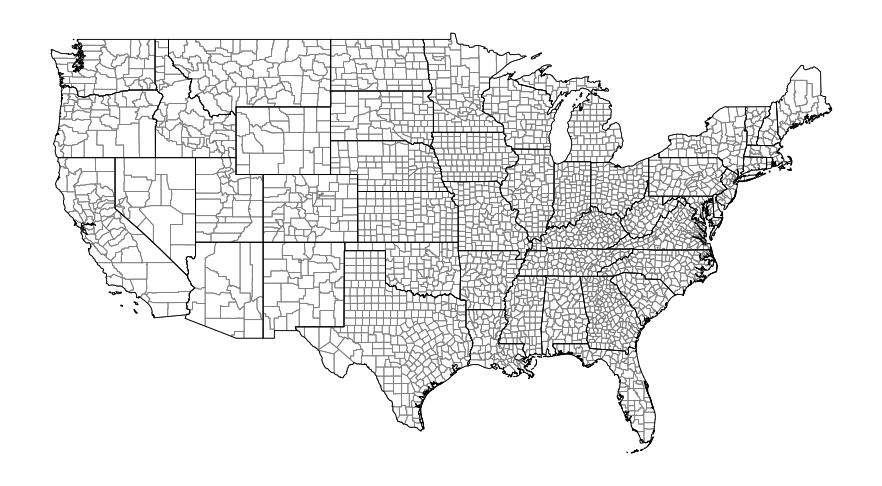

In [8]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

counties.plot(facecolor='none', edgecolor='gray', linewidth=0.5, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

ax.axis('off')

plt.show()


## Analyzing premiums and subsidies

In [9]:
premiums_subsidies_indemnities = df[['commodity_year', 'total_premium', 'subsidy', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
premiums_subsidies_indemnities.head()


,commodity_year,total_premium,subsidy,indemnity
0,1990,69716814.0,20513514.0,87565111.0
1,1991,78351779.0,23071048.0,159391783.0
2,1992,88342523.0,25977769.0,284540548.0
3,1993,103097260.0,30320580.0,106495764.0
4,1994,127312690.0,37705916.0,80616255.0


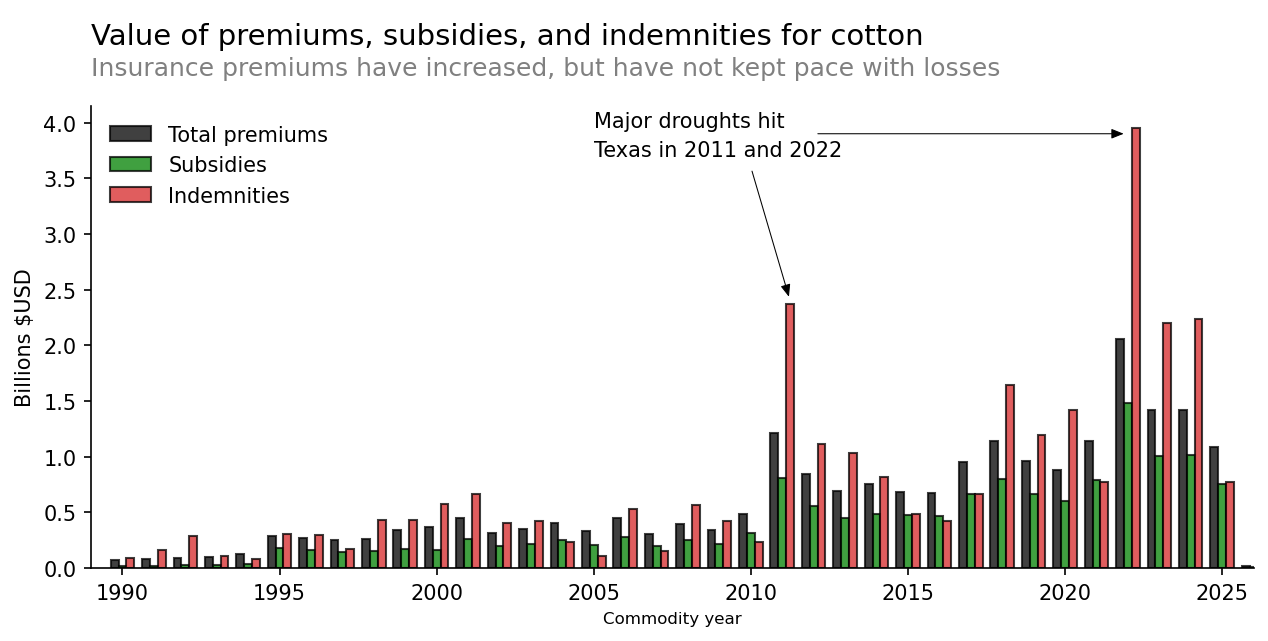

In [10]:
width = 0.25
multiplier = -1
x = premiums_subsidies_indemnities.commodity_year.values

arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

for col, values in premiums_subsidies_indemnities.drop('commodity_year', axis=1).items():

    if col == 'total_premium':
        color = 'black'
        label = 'Total premiums'
    elif col == 'subsidy':
        color = 'green'
        label = 'Subsidies'
    else:
        color = 'tab:red'
        label = 'Indemnities'
    
    offset = width * multiplier
    
    rects = ax.bar(
        x + offset, values, 
        width, 
        color=color,
        edgecolor='black', 
        alpha=0.75,
        label=label,
    )
    
    multiplier += 1

ax.set_xlabel('Commodity year', size=8)

ax.set_xlim([1989, 2026])
ax.set_yticks(ticks=np.arange(0, 4.5e9, 0.5e9), labels=np.arange(0, 4.5, 0.5))
ax.set_ylabel('Billions $USD')

ax.legend(loc='upper left', frameon=False)

s = f'Value of premiums, subsidies, and indemnities for {CROP}'
ax_text(x=1989, y=4.9e9, s=s, size=14, ha='left')

s = 'Insurance premiums have increased, but have not kept pace with losses'
ax_text(x=1989, y=4.6e9, s=s, size=12, color='gray', ha='left')
ax_arrow(tail_position=(2010, 3.6e9), head_position=(2011.25, 2.4e9), **arrow_props)

s = 'Major droughts hit\nTexas in 2011 and 2022'
ax_text(x=2005, y=4.1e9, s=s, size=10, ha='left')
ax_arrow(tail_position=(2012, 3.9e9), head_position=(2022, 3.9e9), **arrow_props)

ax.spines[['top', 'right']].set_visible(False)

plt.show()


So subsidies for cotton continue to rise through time. Crop insurance premiums go up, but do not keep pace with indemnities (meaning the program is a loss for cotton).

## Indemnities

### By time

In [11]:
val_indemnities_by_year = df[['commodity_year', 'indemnity']].groupby(by='commodity_year').sum().reset_index(drop=False)
val_indemnities_by_year


,commodity_year,indemnity
0,1990,8.756511e+07
1,1991,1.593918e+08
2,1992,2.845405e+08
3,1993,1.064958e+08
4,1994,8.061626e+07
5,1995,3.081820e+08
6,1996,2.949319e+08
7,1997,1.700681e+08
8,1998,4.290739e+08
9,1999,4.335905e+08


In [12]:
val_indemnities_by_state_and_year = df[['state', 'commodity_year', 'indemnity']].groupby(by=['state', 'commodity_year']).sum()
val_indemnities_by_state_and_year = val_indemnities_by_state_and_year.reset_index()
val_indemnities_by_state_and_year


,state,commodity_year,indemnity
0,AL,1990,2605568.0
1,AL,1991,1673796.0
2,AL,1992,1487431.0
3,AL,1993,3015718.0
4,AL,1994,2351050.0
...,...,...,...
618,VA,2022,4167843.0
619,VA,2023,589395.0
620,VA,2024,683954.0
621,VA,2025,1865993.0


In [13]:
val_indemnities_by_year_texas = val_indemnities_by_state_and_year.query(" state == 'TX' ")
val_indemnities_by_year_texas


,state,commodity_year,indemnity
550,TX,1990,6.990306e+07
551,TX,1991,1.315779e+08
552,TX,1992,2.512148e+08
553,TX,1993,6.659880e+07
554,TX,1994,6.173596e+07
555,TX,1995,1.871620e+08
556,TX,1996,2.406872e+08
557,TX,1997,7.859571e+07
558,TX,1998,3.023636e+08
559,TX,1999,2.178889e+08


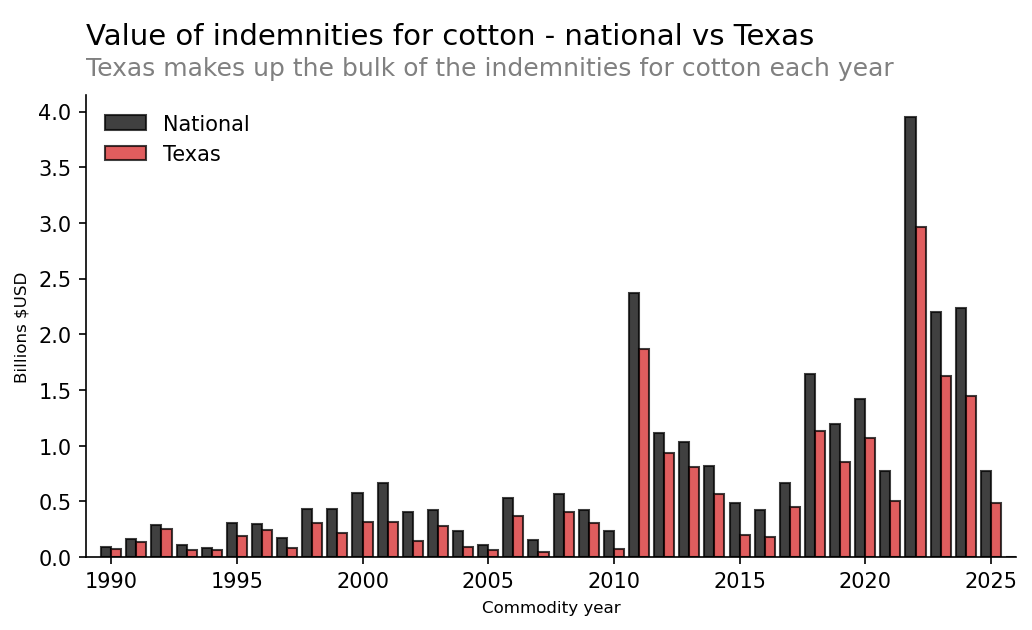

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

ax.bar(
    val_indemnities_by_year.commodity_year, val_indemnities_by_year.indemnity, 
    color='black', edgecolor='black', alpha=0.75, width=-0.4, align='edge', label='National',
)

ax.bar(
    val_indemnities_by_year_texas.commodity_year, val_indemnities_by_year_texas.indemnity, 
    color='tab:red', edgecolor='black', alpha=0.75, align='edge', width=0.4, label='Texas',
)

ax.set_xlabel('Commodity year', size=8)

ax.set_xlim([1989, 2026])
ax.set_yticks(ticks=np.arange(0, 4.5e9, 0.5e9), labels=np.arange(0, 4.5, 0.5))
ax.set_ylabel('Billions $USD', size=8)

s = f'Value of indemnities for {CROP} - national vs Texas'
ax_text(x=1989, y=4.8e9, s=s, size=14, ha='left')

s = f'Texas makes up the bulk of the indemnities for {CROP} each year'
ax_text(x=1989, y=4.5e9, s=s, size=12, color='gray', ha='left')

ax.legend(loc='upper left', frameon=False)

ax.spines[['top', 'right']].set_visible(False)

plt.show()


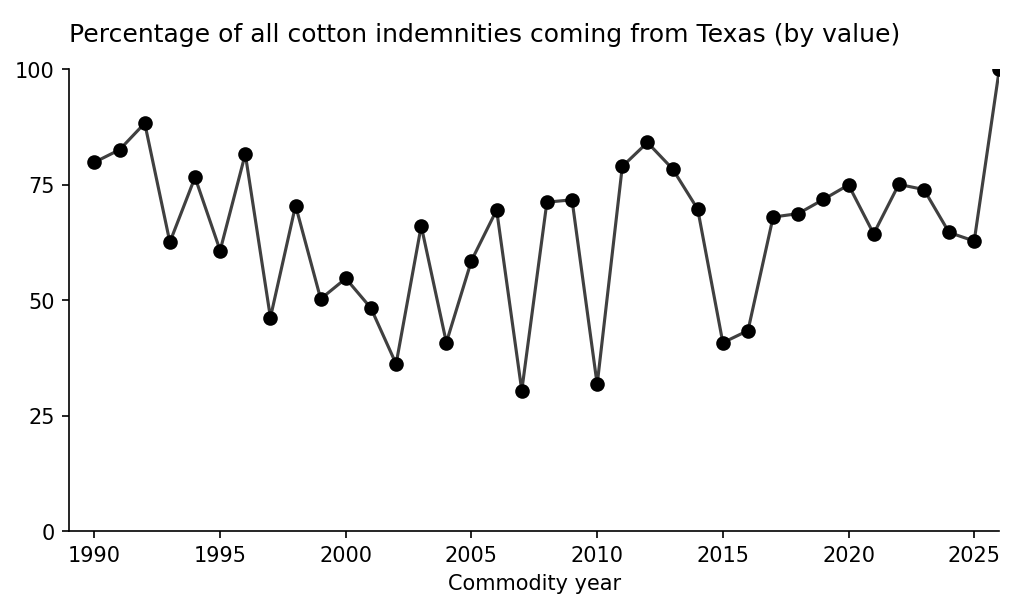

In [15]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

ax.plot(
    val_indemnities_by_year.commodity_year, 
    val_indemnities_by_year_texas.indemnity.values / val_indemnities_by_year.indemnity.values * 100, 
    color='black', alpha=0.75
)

ax.scatter(
    val_indemnities_by_year.commodity_year, 
    val_indemnities_by_year_texas.indemnity.values / val_indemnities_by_year.indemnity.values * 100, 
    color='black'
)

ax.set_xlim([1989, 2026])
ax.set_xlabel('Commodity year', size=10)

ax.set_ylim([0, 100])
ax.set_yticks(ticks=np.arange(0, 125, 25))
ax.set_ylabel('')

s = f'Percentage of all {CROP} indemnities coming from Texas (by value)'
ax_text(x=1989, y=110, s=s, size=12, ha='left')

ax.spines[['top', 'right']].set_visible(False)

plt.show()

### By state

In [16]:
num_indemnities_by_state = df[['state', 'policies_indemnified']].groupby(by='state').sum()
num_indemnities_by_state = num_indemnities_by_state.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_state = num_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'policies_indemnified', 'geometry']]
num_indemnities_by_state = gpd.GeoDataFrame(num_indemnities_by_state).set_geometry('geometry')
num_indemnities_by_state = num_indemnities_by_state.query(" policies_indemnified > 0 ")
num_indemnities_by_state


,state,name,policies_indemnified,geometry
0,TX,Texas,554560,"MULTIPOLYGON (((-103.31151 29.02604, -103.3099..."
1,GA,Georgia,68611,"MULTIPOLYGON (((-80.89029 32.03266, -80.88939 ..."
2,OK,Oklahoma,30203,"POLYGON ((-103.00024 36.5002, -103.00036 36.62..."
3,AL,Alabama,24826,"MULTIPOLYGON (((-87.41958 30.4796, -87.42683 3..."
4,NC,North Carolina,21676,"MULTIPOLYGON (((-76.03173 36.55028, -76.03091 ..."
5,MS,Mississippi,12752,"MULTIPOLYGON (((-88.40221 30.38783, -88.40315 ..."
6,SC,South Carolina,10789,"MULTIPOLYGON (((-78.57316 33.8826, -78.60001 3..."
7,LA,Louisiana,10385,"MULTIPOLYGON (((-89.52599 30.19278, -89.53637 ..."
8,TN,Tennessee,7359,"POLYGON ((-90.30422 35.00008, -90.31266 35.012..."
9,AR,Arkansas,7059,"POLYGON ((-90.30422 35.00008, -90.30124 34.995..."


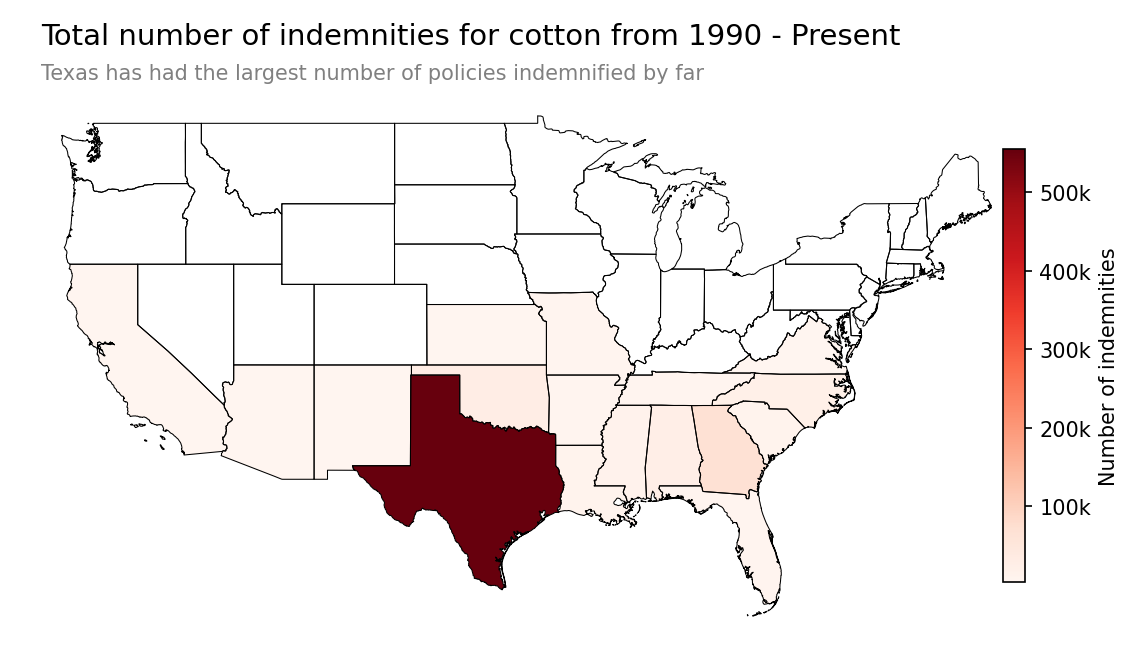

In [17]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_state.plot(column='policies_indemnified', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_state['policies_indemnified'].min()
vmax = num_indemnities_by_state['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(100000, 600000, 100000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(100, 600, 100)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = 'Texas has had the largest number of policies indemnified by far'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')
ax.axis('off')

plt.show()


In [18]:
val_indemnities_by_state = df[['state', 'indemnity']].groupby(by='state').sum()
val_indemnities_by_state = val_indemnities_by_state.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_state = val_indemnities_by_state.merge(states, on='state', how='left')[['state', 'name', 'indemnity', 'geometry']]
val_indemnities_by_state = gpd.GeoDataFrame(val_indemnities_by_state).set_geometry('geometry')
val_indemnities_by_state = val_indemnities_by_state.query(" indemnity > 0 ")
val_indemnities_by_state


,state,name,indemnity,geometry
0,TX,Texas,1.911175e+10,"MULTIPOLYGON (((-103.31151 29.02604, -103.3099..."
1,GA,Georgia,2.157593e+09,"MULTIPOLYGON (((-80.89029 32.03266, -80.88939 ..."
2,OK,Oklahoma,1.244503e+09,"POLYGON ((-103.00024 36.5002, -103.00036 36.62..."
3,CA,California,9.504137e+08,"MULTIPOLYGON (((-114.72428 32.71284, -114.7645..."
4,MS,Mississippi,6.981746e+08,"MULTIPOLYGON (((-88.40221 30.38783, -88.40315 ..."
5,AL,Alabama,6.284222e+08,"MULTIPOLYGON (((-87.41958 30.4796, -87.42683 3..."
6,NC,North Carolina,6.102980e+08,"MULTIPOLYGON (((-76.03173 36.55028, -76.03091 ..."
7,AZ,Arizona,4.855961e+08,"POLYGON ((-111.00627 31.32718, -111.06712 31.3..."
8,LA,Louisiana,3.536072e+08,"MULTIPOLYGON (((-89.52599 30.19278, -89.53637 ..."
9,SC,South Carolina,3.515674e+08,"MULTIPOLYGON (((-78.57316 33.8826, -78.60001 3..."


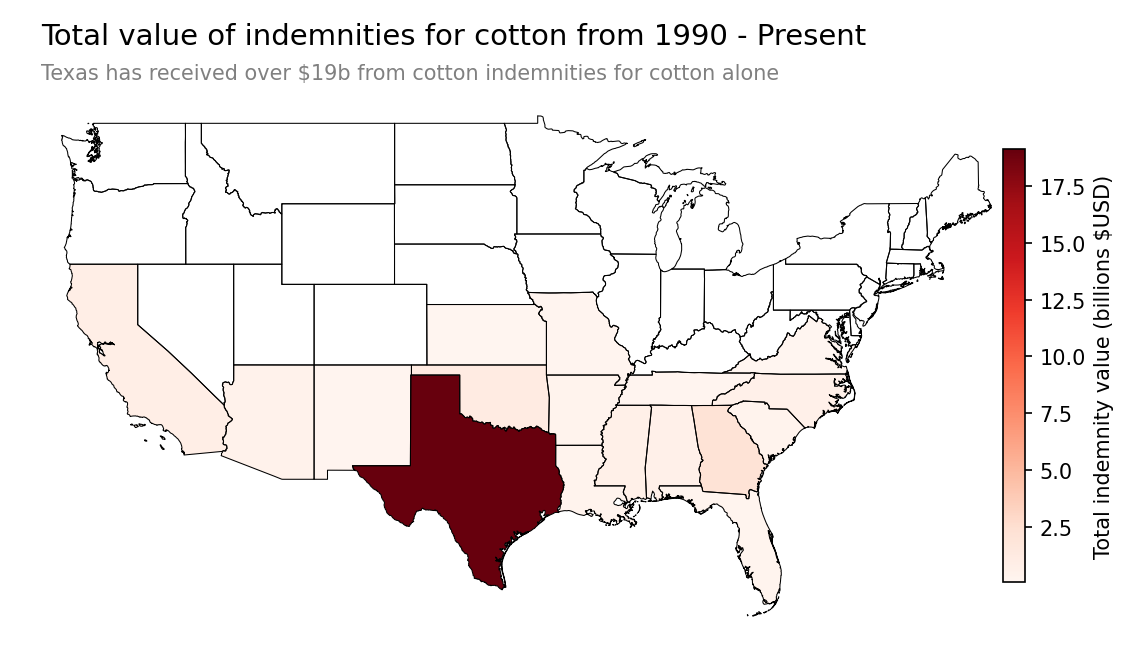

In [20]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_state.plot(column='indemnity', cmap='Reds', ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_state['indemnity'].min()
vmax = val_indemnities_by_state['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0.25e10, 2e10, 0.25e10))
cbar.set_ticklabels([val * 10 for val in np.arange(0.25, 2, 0.25)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'Texas has received over $19b from {CROP} indemnities for {CROP} alone'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')

ax.axis('off')

plt.show()


### By county

In [21]:
num_indemnities_by_county = df[['fips', 'county_name', 'policies_indemnified']].groupby(by=['fips', 'county_name']).sum()
num_indemnities_by_county = num_indemnities_by_county.sort_values(by='policies_indemnified', ascending=False).reset_index()
num_indemnities_by_county = num_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'policies_indemnified', 'geometry']]
num_indemnities_by_county = gpd.GeoDataFrame(num_indemnities_by_county).set_geometry('geometry')
num_indemnities_by_county = num_indemnities_by_county.query(" policies_indemnified > 0 ")
num_indemnities_by_county


,state,name,fips,policies_indemnified,geometry
0,TX,Lubbock,48303,30520,"POLYGON ((-101.56357 33.83045, -101.55831 33.5..."
1,TX,Dawson,48115,27309,"POLYGON ((-101.69128 32.96183, -101.69059 32.7..."
2,TX,Lynn,48305,26363,"POLYGON ((-101.55743 32.96102, -101.69128 32.9..."
3,TX,Hockley,48219,24509,"POLYGON ((-102.59483 33.38848, -102.60057 33.5..."
4,TX,Terry,48445,21917,"POLYGON ((-102.07621 32.9597, -102.20851 32.95..."
...,...,...,...,...,...
628,AR,Arkansas,05001,2,"POLYGON ((-91.37777 34.56348, -91.29224 34.561..."
629,GA,Walton,13297,1,"POLYGON ((-83.7991 33.92984, -83.76469 33.8986..."
630,TX,Tarrant,48439,1,"POLYGON ((-97.03238 32.98462, -97.03309 32.876..."
631,TX,Gonzales,48177,1,"POLYGON ((-97.63311 29.64993, -97.59775 29.630..."


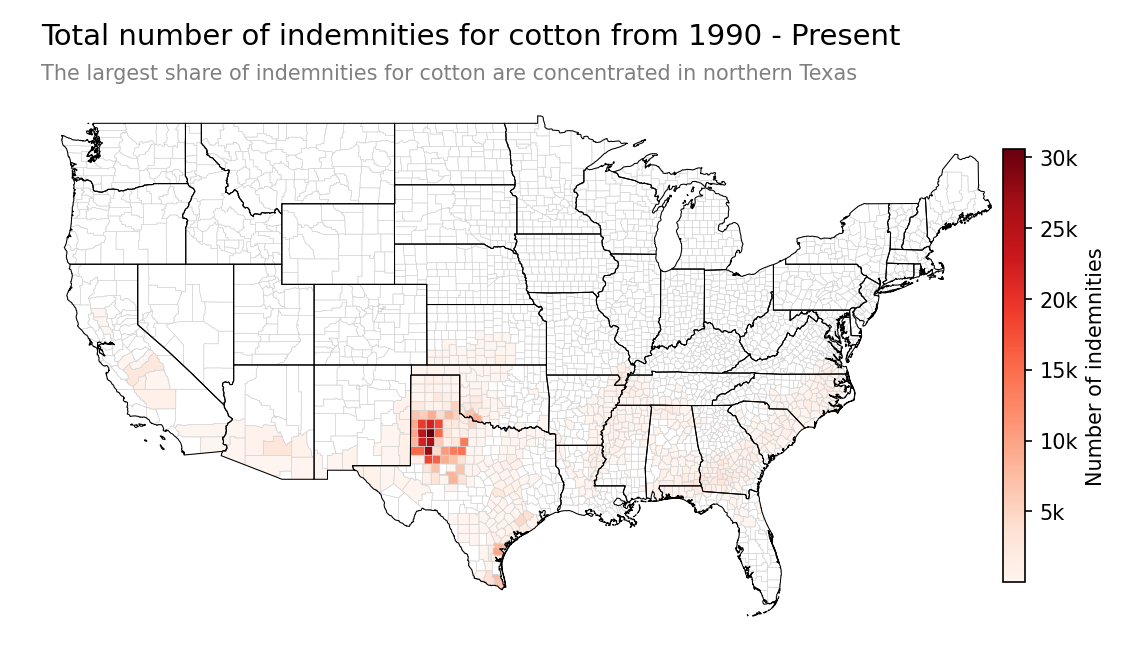

In [22]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

num_indemnities_by_county.plot(column='policies_indemnified', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = num_indemnities_by_county['policies_indemnified'].min()
vmax = num_indemnities_by_county['policies_indemnified'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(5000, 35000, 5000))
cbar.set_ticklabels([str(val)+'k' for val in np.arange(5, 35, 5)])
cbar.set_label('Number of indemnities')

s = f'Total number of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=54, s=s, size=14, color='black', ha='left')

s = f'The largest share of indemnities for {CROP} are concentrated in northern Texas'
ax_text(x=-126, y=52, s=s, size=10, color='gray', ha='left')
ax.axis('off')

plt.show()


In [24]:
val_indemnities_by_county = df[['fips', 'county_name', 'indemnity']].groupby(by=['fips', 'county_name']).sum()
val_indemnities_by_county = val_indemnities_by_county.sort_values(by='indemnity', ascending=False).reset_index()
val_indemnities_by_county = val_indemnities_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'indemnity', 'geometry']]
val_indemnities_by_county = gpd.GeoDataFrame(val_indemnities_by_county).set_geometry('geometry')
val_indemnities_by_county = val_indemnities_by_county.query(" indemnity > 0 ")
val_indemnities_by_county


,state,name,fips,indemnity,geometry
0,TX,Gaines,48165,1.288214e+09,"POLYGON ((-103.06279 32.52218, -103.06259 32.5..."
1,TX,Dawson,48115,1.007904e+09,"POLYGON ((-101.69128 32.96183, -101.69059 32.7..."
2,TX,Lynn,48305,8.609385e+08,"POLYGON ((-101.55743 32.96102, -101.69128 32.9..."
3,TX,Terry,48445,8.055480e+08,"POLYGON ((-102.07621 32.9597, -102.20851 32.95..."
4,TX,Hale,48189,7.836207e+08,"POLYGON ((-102.09041 34.31313, -101.99801 34.3..."
...,...,...,...,...,...
628,TX,Gonzales,48177,9.266000e+03,"POLYGON ((-97.63311 29.64993, -97.59775 29.630..."
629,OK,Woodward,40153,7.408000e+03,"POLYGON ((-98.95584 36.16157, -99.12557 36.162..."
630,AR,Clark,05019,4.445000e+03,"POLYGON ((-93.40812 34.33952, -93.35579 34.338..."
631,GA,Bartow,13015,3.846000e+03,"POLYGON ((-84.65923 34.07799, -84.73783 34.079..."


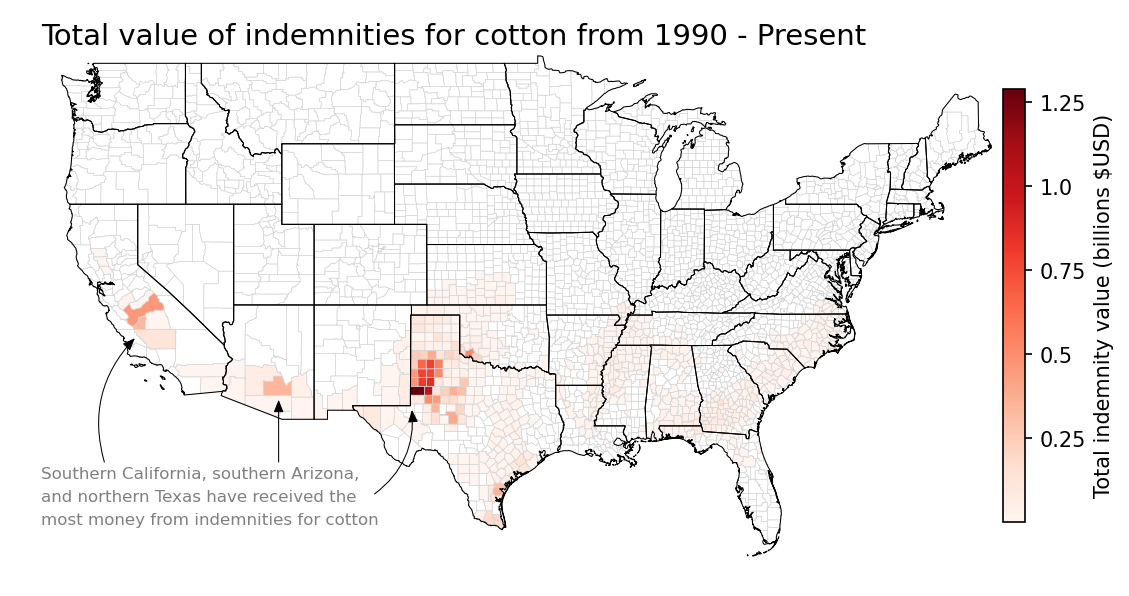

In [25]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

val_indemnities_by_county.plot(column='indemnity', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = val_indemnities_by_county['indemnity'].min()
vmax = val_indemnities_by_county['indemnity'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_ticks(np.arange(0.25e9, 1.5e9, 0.25e9))
cbar.set_ticklabels([val for val in np.arange(0.25, 1.5, 0.25)])
cbar.set_label('Total indemnity value (billions $USD)', fontsize=10)

s = f'Total value of indemnities for {CROP} from 1990 - Present'
ax_text(x=-126, y=51, s=s, size=14, color='black', ha='left')

s = f'Southern California, southern Arizona,\nand northern Texas have received the \nmost money from indemnities for {CROP}'
ax_text(x=-126, y=29, s=s, size=8, color='gray', ha='left')

# order: california, arizona, texas
ax_arrow(tail_position=(-122, 29), head_position=(-120, 35.5), invert=True, radius=0.3, **arrow_props)
ax_arrow(tail_position=(-111.25, 29), head_position=(-111.25, 32.5), radius=0, **arrow_props)
ax_arrow(tail_position=(-105.5, 27.5), head_position=(-103, 32), invert=False, radius=0.3, **arrow_props)

ax.axis('off')

plt.show()


In [26]:
loss_ratio_by_county = df[['fips', 'county_name', 'loss_ratio']].groupby(by=['fips', 'county_name']).mean()
loss_ratio_by_county = loss_ratio_by_county.sort_values(by='loss_ratio', ascending=False).reset_index()
loss_ratio_by_county = loss_ratio_by_county.merge(counties, on='fips', how='left')[['state', 'name', 'fips', 'loss_ratio', 'geometry']]
loss_ratio_by_county = gpd.GeoDataFrame(loss_ratio_by_county).set_geometry('geometry')
loss_ratio_by_county = loss_ratio_by_county.query(" loss_ratio > 0 ")
loss_ratio_by_county


,state,name,fips,loss_ratio,geometry
0,TX,Hamilton,48193,3.299091,"POLYGON ((-98.00544 32.01788, -97.9242 31.9001..."
1,TX,Bosque,48035,2.379878,"POLYGON ((-97.61513 32.21522, -97.59854 32.212..."
2,OK,Jefferson,40067,1.765000,"POLYGON ((-97.96594 33.99327, -98.00143 34.003..."
3,AL,Greene,01063,1.660000,"POLYGON ((-87.72688 33.00983, -87.74795 33.003..."
4,TX,Hudspeth,48229,1.645067,"POLYGON ((-104.98276 30.62072, -104.98912 30.6..."
...,...,...,...,...,...
628,SC,Edgefield,45037,0.064118,"POLYGON ((-82.0274 33.54571, -82.04094 33.5600..."
629,KS,Stanton,20187,0.055459,"POLYGON ((-102.04107 37.38919, -102.0414 37.46..."
630,AR,Clark,05019,0.026250,"POLYGON ((-93.40812 34.33952, -93.35579 34.338..."
631,GA,Bartow,13015,0.015000,"POLYGON ((-84.65923 34.07799, -84.73783 34.079..."


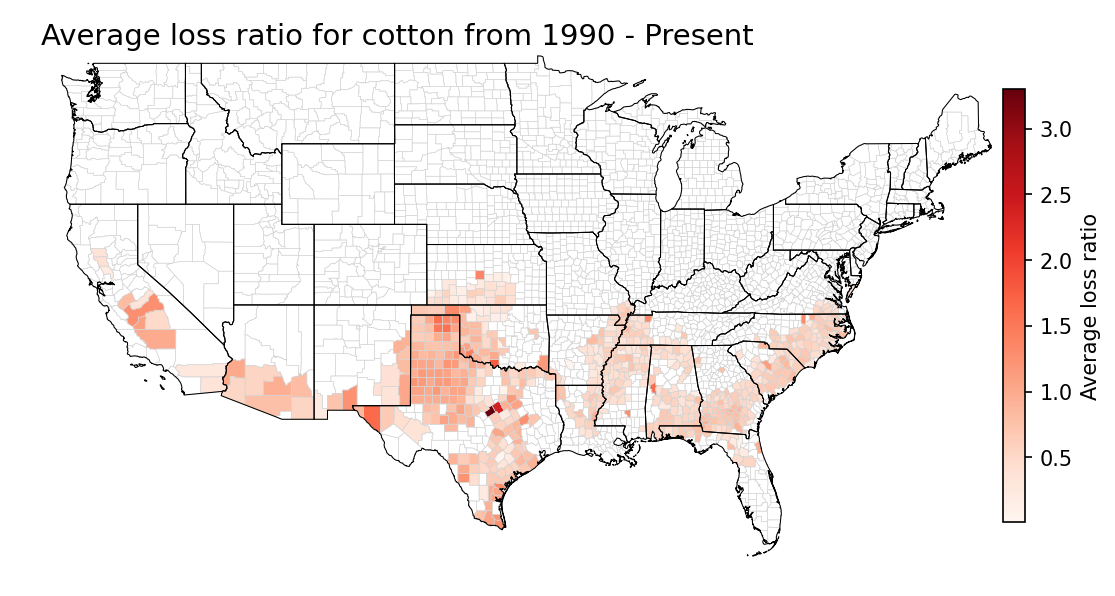

In [27]:
arrow_props = dict(
    color='black', 
    width=0.5, 
    head_width=2, 
    head_length=5,
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

loss_ratio_by_county.plot(column='loss_ratio', cmap='Reds', ax=ax)
counties.plot(facecolor='none', edgecolor='lightgray', linewidth=0.25, ax=ax)
states.plot(facecolor='none', edgecolor='black', linewidth=0.5, ax=ax)

vmin = loss_ratio_by_county['loss_ratio'].min()
vmax = loss_ratio_by_county['loss_ratio'].max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
mapper = plt.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(mapper, shrink=0.75, ax=ax, pad=-0.03)
cbar.set_label('Average loss ratio')

s = f'Average loss ratio for {CROP} from 1990 - Present'
ax_text(x=-126, y=51, s=s, size=14, color='black', ha='left')

ax.axis('off')

plt.show()
